In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys, os 
from data_loading import load_runs
from microfit.histogram import Binning, Histogram, RunHistGenerator

# Runs 4 and 5 Nue
RUN = ["4a_nuepresel_testsplit","4b_nuepresel_testsplit","4c_nuepresel_testsplit","4d_nuepresel_testsplit","5_nuepresel_testsplit"]
# RUN = ["4a_nuepresel_testsplit","4b_nuepresel_testsplit","4c_nuepresel_testsplit"]
# RUN = ["5_nuepresel_testsplit"]
# RUN = ["4a_1shower","4b_1shower","4c_1shower","4d_1shower"]
# RUN = ["4a_1shower","4b_1shower","4c_1shower","4d_1shower","5_1shower"]
# MCC9 BDT test samples
# RUN = ["4a_testsplit","4b_testsplit","4c_testsplit","4d_testsplit","5_testsplit"]
rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",
    truth_filtered_sets=["nue", "drt", "nc_pi0"],
    # truth_filtered_sets=["nue", "drt"],
    loadpi0variables=True,
    loadshowervariables=True,
    loadrecoveryvars=True,
    loadsystematics=False,    # Set to false when we don't have event weights
    load_crt_vars=True,
    use_bdt = True,
    load_lee=False,
    enable_cache=True,
    blinded=True,
)

Loading run 4a_nuepresel_testsplit
Loading run 4b_nuepresel_testsplit
Loading run 4c_nuepresel_testsplit
Loading run 4d_nuepresel_testsplit
Loading run 5_nuepresel_testsplit


In [4]:
df_nu=rundata["mc"]
df_nue=rundata["nue"]
df_dirt=rundata["drt"]
df_ncpi0=rundata["nc_pi0"]
df_ext=rundata["ext"]

In [5]:
print(df_nue["category"])
print(df_nue["is_signal"])

0         11
1          1
2         10
3         10
4         11
          ..
102672     1
102673    11
102674     1
102675     1
102676     5
Name: category, Length: 350757, dtype: int32
0          True
1         False
2         False
3         False
4          True
          ...  
102672    False
102673     True
102674    False
102675    False
102676    False
Name: is_signal, Length: 350757, dtype: bool


In [6]:
# print(data_loading.py)

In [7]:
from sklearn.model_selection import train_test_split

train_nu, test_nu = train_test_split(df_nu, test_size=0.5, random_state=1990)
train_nue, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
train_ncpi0, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

In [8]:
# print(test_nu["run"])
# print(test_nue["run"])
# print(test_dirt["run"])
# print(test_ncpi0["run"])
# print(test_ext["run"])

In [9]:
rundata["mc"]=test_nu
rundata["nue"]=test_nue
rundata["drt"]=test_dirt
rundata["nc_pi0"]=test_ncpi0
rundata["ext"]=test_ext

In [10]:
crt_vars = [
    ("crtveto", 2, (0,2), "crtveto"),
    ("crtveto", 1, (0,2), "crtveto"),
    ("_closestNuCosmicDist", 20, (0, 100), "_closestNuCosmicDist"),
]

second_shr = [
    ("shr_energy_tot_cali", 16, (0, 4), "shr_energy_tot_cali"),
    ("anglediff_U", 25, (0, 300), "anglediff_U"),
    ("secondshower_U_dot", 25, (0, 1), "secondshower_U_dot"),
    ("secondshower_U_nhit", 25, (0, 100), "secondshower_U_nhit"),
    ("secondshower_U_vtxdist", 25, (0, 200), "secondshower_U_vtxdist"),
    ("anglediff_V", 25, (0, 300), "anglediff_V"),
    ("secondshower_V_dot", 25, (0, 1), "secondshower_V_dot"),
    ("secondshower_V_nhit", 25, (0, 100), "secondshower_V_nhit"),
    ("secondshower_V_vtxdist", 25, (0, 200), "secondshower_V_vtxdist"),
    ("anglediff_Y", 25, (0, 300), "anglediff_Y"),
    ("secondshower_Y_dot", 25, (0, 1), "secondshower_Y_dot"),
    ("secondshower_Y_nhit", 25, (0, 100), "secondshower_Y_nhit"),
    ("secondshower_Y_vtxdist", 25, (0, 200), "secondshower_Y_vtxdist"),
]


dedx_vars = [
    ("shr_dedx_Y", 25, (0, 10), "shr_dedx_Y"),
    ("shr_tkfit_dedx_U", 25, (0, 10), "shr_tkfit_dedx_U"),
    ("shr_tkfit_dedx_V", 25, (0, 10), "shr_tkfit_dedx_V"),
    ("shr_tkfit_dedx_Y", 25, (0, 10), "shr_tkfit_dedx_Y"),
    ("shr_tkfit_gap10_dedx_U", 25, (0, 10), "shr_tkfit_gap10_dedx_U"),
    ("shr_tkfit_gap10_dedx_V", 25, (0, 10), "shr_tkfit_gap10_dedx_V"),
    ("shr_tkfit_gap10_dedx_Y", 25, (0, 10), "shr_tkfit_gap10_dedx_Y"),
    ("shr_tkfit_2cm_dedx_U", 25, (0, 10), "shr_tkfit_2cm_dedx_U"),
    ("shr_tkfit_2cm_dedx_V", 25, (0, 10), "shr_tkfit_2cm_dedx_V"),
    ("shr_tkfit_2cm_dedx_Y", 25, (0, 10), "shr_tkfit_2cm_dedx_Y"),
    ("shr_tkfit_dedx_max", 25, (0, 10), "shr_tkfit_dedx_max"),
    ("shr_tkfit_2cm_dedx_max", 25, (0, 10), "shr_tkfit_2cm_dedx_max"),
    ("shr_tkfit_gap10_dedx_max", 25, (0, 10), "shr_tkfit_gap10_dedx_max"),
    # ("shr_dedx_Y", 25, (7, 30), "shr_dedx_Y"),
    # ("shr_tkfit_dedx_U", 25, (7, 30), "shr_tkfit_dedx_U"),
    # ("shr_tkfit_dedx_V", 25, (7, 30), "shr_tkfit_dedx_V"),
    # ("shr_tkfit_dedx_Y", 25, (7, 30), "shr_tkfit_dedx_Y"),
    # ("shr_tkfit_gap10_dedx_U", 25, (7, 30), "shr_tkfit_gap10_dedx_U"),
    # ("shr_tkfit_gap10_dedx_V", 25, (7, 30), "shr_tkfit_gap10_dedx_V"),
    # ("shr_tkfit_gap10_dedx_Y", 25, (7, 30), "shr_tkfit_gap10_dedx_Y"),
    # ("shr_tkfit_2cm_dedx_U", 25, (7, 30), "shr_tkfit_2cm_dedx_U"),
    # ("shr_tkfit_2cm_dedx_V", 25, (7, 30), "shr_tkfit_2cm_dedx_V"),
    # ("shr_tkfit_2cm_dedx_Y", 25, (7, 30), "shr_tkfit_2cm_dedx_Y"),
]

zp_variables_loose_bdt = [
    ("slice_orig_pass_id", 1, (0, 2), "slice_orig_pass_id"),
    ("CosmicIPAll3D", 25, (0, 300), "CosmicIPAll3D"),
    ("CosmicIPAll3D", 25, (0, 50), "CosmicIPAll3D"),
    ("CosmicDirAll3D", 25, (-1, 1), "CosmicDirAll3D"),
    ("CosmicDirAll3D", 25, (0, 1), "CosmicDirAll3D"),
    ("shrmoliereavg", 25, (0, 50), "shrmoliereavg"),
    ("subcluster", 25, (0, 70), "subcluster"),
    ("subcluster", 10, (0, 20), "subcluster"),
    ("trkfit", 25, (0, 1), "trkfit"),
    ("secondshower_Y_nhit", 25, (0, 100), "secondshower_Y_nhit"),
    ("secondshower_Y_nhit", 25, (20, 100), "secondshower_Y_nhit"),
    ("shr_trk_sce_start_y", 25, (-150, 150), "shr_trk_sce_start_y"),
    ("shr_trk_sce_end_y", 25, (-150, 150), "shr_trk_sce_end_y"),
    ("shr_trk_len", 25, (0, 200), "shr_trk_len"),
    ("shr_trk_len", 25, (80, 300), "shr_trk_len"),
    ("shr_trk_len", 25, (0, 40), "shr_trk_len"),
    ("tk1sh1_angle_alltk", 25, (-1.2, 1.2), "tk1sh1_angle_alltk"),
    ("CylFrac2h_1cm", 25, (0, 1), "CylFrac2h_1cm"),
    ("CylFrac2h_1cm", 25, (0.3, 0.7), "CylFrac2h_1cm"),
    ("CylFrac2h_1cm", 25, (0.2, 1), "CylFrac2h_1cm"),
    ("DeltaRMS2h", 25, (-0.5, 30), "DeltaRMS2h"),
    ("DeltaRMS2h", 25, (0, 10), "DeltaRMS2h"),
    ("DeltaRMS2h", 25, (10, 30), "DeltaRMS2h"),
    ("shrMCSMom", 25, (0, 400), "shrMCSMom"),
    ("shrMCSMom", 25, (0, 50), "shrMCSMom"),
    ("shrMCSMom", 25, (200, 600), "shrMCSMom"),
    ("shrPCA1CMed_5cm", 25, (0, 1), "shrPCA1CMed_5cm"),
    ("shr_score", 25, (-0.1, 0.1), "shr_score"),
    ("shr_tkfit_2cm_dedx_U", 25, (0, 8), "shr_tkfit_2cm_dedx_U"),
    ("shr_tkfit_2cm_dedx_V", 25, (0, 8), "shr_tkfit_2cm_dedx_V"),
    ("shr_tkfit_2cm_dedx_Y", 25, (0, 8), "shr_tkfit_2cm_dedx_Y"),
    ("shr_tkfit_gap10_dedx_U", 25, (0, 8), "shr_tkfit_gap10_dedx_U"),
    ("shr_tkfit_gap10_dedx_V", 25, (0, 8), "shr_tkfit_gap10_dedx_V"),
    ("shr_tkfit_gap10_dedx_Y", 25, (0, 8), "shr_tkfit_gap10_dedx_Y"),
    ("diffY", 25, (-95, 95), "ChargeY - FlashY [cm]"),
    ("normdiffY", 25, (-2.3, 2.3), "(ChargeY - FlashY) / FlashwidthY"),
    ("diffZ", 25, (-115, 115), "ChargeZ - FlashZ [cm]"),
    ("normdiffZ", 25, (-1.0, 1.0), "(ChargeZ - FlashZ) / FlashwidthZ"),
    ("fnl", 25, (-320, 120), "m.log(Charge/Flash) - ChargeX"),
]

nugraph_vars = [
    ("slice_orig_pass_id", 1, (0, 2), "slice_orig_pass_id"),
    ("slcng2mip", 20, (0, 100), "slcng2mip"),
    # ("slcng2mip", 20, (10, 300), "slcng2mip"),
    ("slcng2hip", 20, (0, 100), "slcng2hip"),
    # ("slcng2hip", 20, (10, 150), "slcng2hip"),
    ("slcng2shr", 20, (0, 500), "slcng2shr"),
    ("slcng2mcl", 20, (0, 100), "slcng2mcl"),
    # ("slcng2mcl", 20, (10, 175), "slcng2mcl"),
    ("slcng2dfs", 20, (0, 300), "slcng2dfs"),
    ("slcng2bkg", 20, (0, 100), "slcng2bkg"),
    # ("slcng2bkg", 20, (10, 300), "slcng2bkg"),
    ("clung2mip", 20, (0, 100), "clung2mip"),
    # ("clung2mip", 20, (10, 300), "clung2mip"),
    ("clung2hip", 20, (0, 100), "clung2hip"),
    # ("clung2hip", 20, (10, 150), "clung2hip"),
    ("clung2shr", 20, (0, 500), "clung2shr"),
    ("clung2mcl", 20, (0, 100), "clung2mcl"),
    # ("clung2mcl", 20, (10, 100), "clung2mcl"),
    ("clung2dfs", 20, (0, 200), "clung2dfs"),
    # ("clung2dfs", 20, (10, 200), "clung2dfs"),
    # ("clung2bkg", 20, (0, 300), "clung2bkg"),
    ("clung2bkg", 20, (0, 100), "clung2bkg"),
    ("nhits_r1cm", 20, (0, 50), "nhits_r1cm"),
    ("nhits_r3cm", 20, (0, 150), "nhits_r3cm"),
    ("nhits_r5cm", 20, (0, 200), "nhits_r5cm"),
    ("nhits_r10cm", 20, (0, 300), "nhits_r10cm"),
    ("ng2hip_r1cm", 20, (0, 25), "ng2hip_r1cm"),
    ("ng2hip_r3cm", 20, (0, 50), "ng2hip_r3cm"),
    ("ng2hip_r5cm", 20, (0, 50), "ng2hip_r5cm"),
    ("ng2hip_r10cm", 20, (0, 100), "ng2hip_r10cm"),
    ("ng2clu_hip_r1cm", 20, (0, 25), "ng2clu_hip_r1cm"),
    ("ng2clu_hip_r3cm", 20, (0, 50), "ng2clu_hip_r3cm"),
    ("ng2clu_hip_r5cm", 20, (0, 50), "ng2clu_hip_r5cm"),
    ("ng2clu_hip_r10cm", 20, (0, 50), "ng2clu_hip_r10cm"),
    ("ng2clu_hippfp_r1cm", 20, (0, 10), "ng2clu_hippfp_r1cm"),
    ("ng2clu_hippfp_r3cm", 20, (0, 10), "ng2clu_hippfp_r3cm"),
    ("ng2clu_hippfp_r5cm", 20, (0, 10), "ng2clu_hippfp_r5cm"),
    ("ng2clu_hippfp_r10cm", 20, (0, 10), "ng2clu_hippfp_r10cm"),
]

slice_var = [
    # ("slice_orig_pass_id", 1, (0, 2), "slice_orig_pass_id"),
    ("shr_energy_tot_cali", 10, (0, 4), "shr_energy_tot_cali"),
    # ("shr_energy_tot_cali", 10, (3, 4), "shr_energy_tot_cali"),
]

bdt_vars = [
    ("pi0_score", 20, (0, 1), "pi0_score"),
    ("nonpi0_score", 20, (0, 1), "nonpi0_score"),
    ("bkg_score", 20, (0, 1), "bkg_score"),
]

proton_vars = [
    ("proton_e", 20, (0,2), "proton_e"),
    ("trk_theta", 20, (-100,100), "trk_theta"),
    ("trk_distance", 20, (0,100), "trk_distance"),
    ("trk_energy", 20, (0,1), "trk_energy"),
    ("tksh_distance", 20, (0,100), "tksh_distance"),
    ("tksh_angle", 20, (-100,100), "tksh_angle"),
    ("trk_hits_tot", 20, (0,10), "trk_hits_tot"),
    ("trk_len", 20, (0,100), "trk_len"),
]

loosesel_variables_1eNp = [
    ("hits_ratio", 20, (0, 1), "hits_ratio, shower hits/all hits"),
    ("trkfit", 20, (0, 1.0), "trkfit, Fraction of Track-fitted points"),
    ("subcluster", 20, (0, 100), "subcluster, N sub-clusters in shower"),
    ("CosmicIPAll3D", 20, (0, 200), "CosmicIPAll3D [cm]"),
    ("shr_tkfit_dedx_max", 20, (0, 10), "shr tkfit dE/dx (max, 0-4 cm) [MeV/cm]"),
    ("tksh_angle", 20, (-1, 1), "tksh_angle, cos(trk-shr angle)"),
    ("tksh_distance", 20, (0, 40), "tksh_distance, trk-shr distance [cm]"),
    ("shr_tkfit_nhits_tot", 20, (0, 40), "shr tkfit nhits (tot, 0-4 cm) [MeV/cm]"),
    ("trkpid", 21, (-1, 1), "trkpid, track LLR PID"),
    ("shrmoliereavg", 20, (0, 20), "shrmoliereavg, average Moliere angle [degrees]"),
    ("shr_trk_len", 40, (0, 200), "shr_trk_len, Shower track fit length [cm]"),
    # ("nonpi0_score", 10, (0, 1.0), "BDT non-$\\pi^0$ score", "log", True),
    # ("pi0_score", 10, (0, 1.0), "BDT $\\pi^0$ score", "log", True),
    # ("bkg_score", 10, (0, 1.0), "1e0p BDT score", "log", True),
]

trksel_variables = [
    ("tksh_angle", 20, (-1, 1), "cos(trk-shr angle)"),
    ("trkshrhitdist2", 20, (0, 10), "2D trk-shr distance (Y)"),
    ("tksh_distance", 20, (0, 40), "trk-shr distance [cm]"),
    # ('tksh_distance',12,(0,6),"trk-shr distance [cm]","zoomed")
    ("trkpid", 21, (-1, 1), "track LLR PID"),
    # ('trkpid',2,(-1,1),"track LLR PID", 'twobins'),
    # ('trkpid',15,(-1,1),"track LLR PID","coarse")
]

trkreco_vars = [
    ("shr_energy_tot_cali", 10, (0, 4), "shr_energy_tot_cali"),
    ("protonenergy_corr", 20, (0,1), "protonenergy_corr, proton kinetic energy"),
    ("cos_trk_theta", 20, (-1.1,1.1), "cos_trk_theta, cosine of proton angle wrt beam"),
    ("n_tracks_contained", 4, (0, 4), "n_tracks_contained"),
    ("tksh_angle", 20, (-1.1, 1.1), "trksh_angle, cos(trk-shr angle)"),
    # ("ng2hip_r1cm", 20, (0, 20), "ng2hip_r1cm"),
    # ("ng2hip_r3cm", 20, (0, 40), "ng2hip_r3cm"),
    # ("ng2hip_r5cm", 20, (0, 40), "ng2hip_r5cm"),
    # ("ng2hip_r10cm", 20, (0, 40), "ng2hip_r10cm"),
    # ("ng2clu_hip_r1cm", 20, (0, 5), "ng2clu_hip_r1cm"),
    # ("ng2clu_hip_r3cm", 20, (0, 10), "ng2clu_hip_r3cm"),
    # ("ng2clu_hip_r5cm", 20, (0, 10), "ng2clu_hip_r5cm"),
    # ("ng2clu_hip_r10cm", 20, (0, 10), "ng2clu_hip_r10cm"),
    # ("ng2clu_hippfp_r1cm", 20, (0, 1), "ng2clu_hippfp_r1cm"),
    # ("ng2clu_hippfp_r3cm", 20, (0, 1), "ng2clu_hippfp_r3cm"),
    # ("ng2clu_hippfp_r5cm", 20, (0, 1), "ng2clu_hippfp_r5cm"),
    # ("ng2clu_hippfp_r10cm", 20, (0, 1), "ng2clu_hippfp_r10cm"),
    # ("slcng2hip", 20, (0, 60), "slcng2hip"),
    # ("clung2hip", 20, (0, 60), "clung2hip"),
]

trueproton_vars = [
    ("proton_ke", 20, (0, 0.3), "proton_ke"),
    ("proton_pz", 20, (-1, 1), "proton_pz"),
    ("nproton", 4, (0, 4), "nproton"),
]

trk_true_reco = [
    ("shr_energy_tot_cali", 10, (0, 4), "shr_energy_tot_cali"),
    ("protonenergy_corr", 20, (0,1), "protonenergy_corr, proton kinetic energy"),
    ("cos_trk_theta", 20, (-1.1,1.1), "cos_trk_theta, cosine of proton angle wrt beam"),
    ("n_tracks_contained", 4, (0, 4), "n_tracks_contained"),
    ("tksh_angle", 20, (-1.1, 1.1), "trksh_angle, cos(trk-shr angle)"),
    ("proton_ke", 20, (0, 0.2), "proton_ke"),
    ("proton_ke", 20, (0, 0.5), "proton_ke"),
    # ("proton_ke", 20, (0.05, 0.5), "proton_ke"),
    ("proton_pz", 20, (-1, 1), "proton_pz"),
    ("nproton", 4, (0, 4), "nproton"),
]

slice_variables_slicecut = [
    ("diffY", 25, (-95, 95), "ChargeY - FlashY [cm]"),
    ("normdiffY", 25, (-2.3, 2.3), "(ChargeY - FlashY) / FlashwidthY"),
    ("diffZ", 25, (-115, 115), "ChargeZ - FlashZ [cm]"),
    ("normdiffZ", 25, (-1.0, 1.0), "(ChargeZ - FlashZ) / FlashwidthZ"),
    ("fnl", 25, (-320, 120), "m.log(Charge/Flash) - ChargeX"),
]

bdt_2bdts_vars = [
    ("bkg_score", 20, (0, 1), "bkg_score"),
    ("pi0_score", 20, (0, 1), "pi0_score"),
    ("nonpi0_score", 20, (0, 1), "nonpi0_score"),
    ("bkg_Np_score", 20, (0, 1), "bkg_Np_score"),
    ("pi0_Np_score", 20, (0, 1), "pi0_Np_score"),
    ("nonpi0_Np_score", 20, (0, 1), "nonpi0_Np_score"),
]

np_bdt_vars = [
    ("bkg_Np_score", 20, (0, 1), "bkg_Np_score"),
    ("pi0_Np_score", 20, (0, 1), "pi0_Np_score"),
    ("nonpi0_Np_score", 20, (0, 1), "nonpi0_Np_score"),
]

In [11]:
# varSet = crt_vars
# varSet = second_shr
# varSet = dedx_vars
# varSet = zp_variables_loose_bdt
varSet = nugraph_vars
# varSet = slice_var
# varSet = slice_variables_slicecut
# varSet = bdt_vars
# varSet = proton_vars
# varSet = loosesel_variables_1eNp
# varSet = trksel_variables
# varSet = trkreco_vars
# varSet = trueproton_vars
# varSet = trk_true_reco
# varSet = bdt_2bdts_vars
# varSet = np_bdt_vars

In [12]:
# preselection = 'None'
# preselection = 'ZP'
preselection = 'ZPCRT'
# preselection = 'NP'
# preselection = 'NUE'

# selection = 'None'
# selection = 'ZPLOOSESEL'
selection = 'ZPLOOSENEW'
# selection = 'LOWCOSMICS'

# selection = 'ZPVETOEXT30'
# selection = 'ZPVETOEXT40'
# selection = 'ZPVETOEXT60'
# selection = 'ZPVETOEXT70'
# selection = 'ZPVETOEXT80'
# selection = 'ZPVETOEXT90'
# selection = 'ZPVETOEXTTIGHT'

/exp/uboone/app/users/kpletcher/PELEE/PELEEMCC10/PELEE/microfit/run_plotter.py:132: UserWarning: No signal category found in the MC hists. Not separating signal.
  warnings.warn("No signal category found in the MC hists. Not separating signal.")
/exp/uboone/app/users/kpletcher/PELEE/PELEEMCC10/PELEE/microfit/run_plotter.py:641: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)


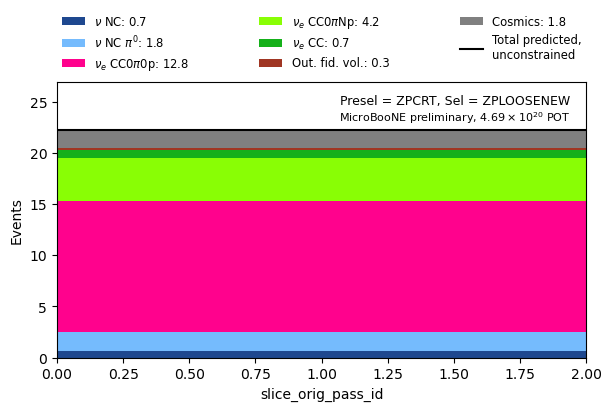

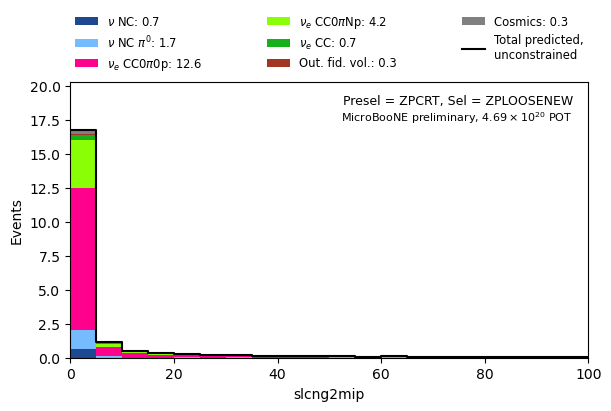

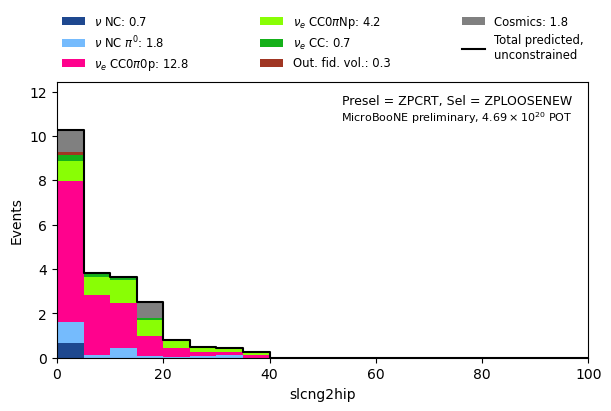

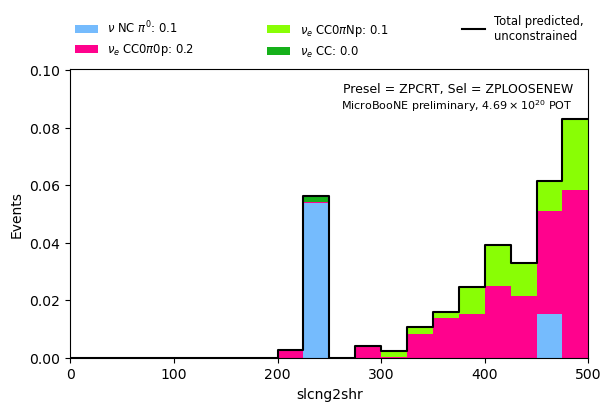

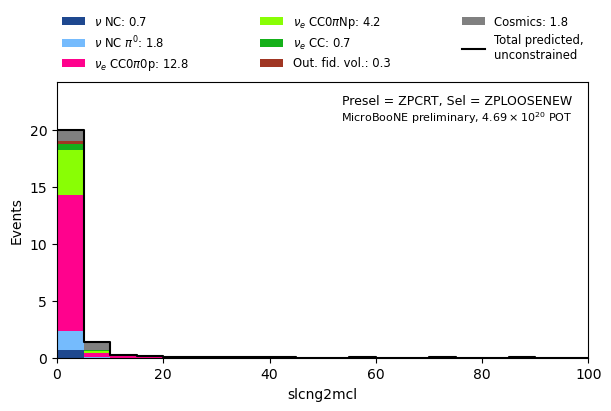

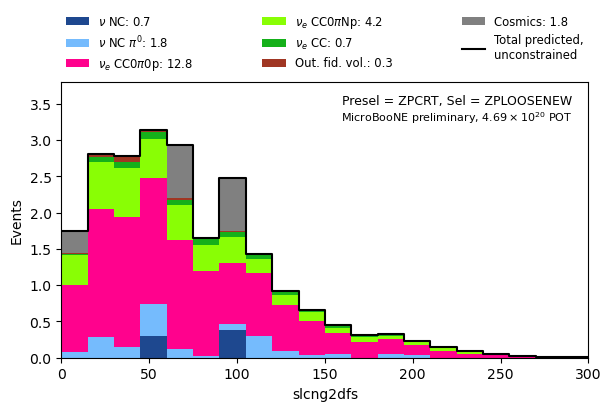

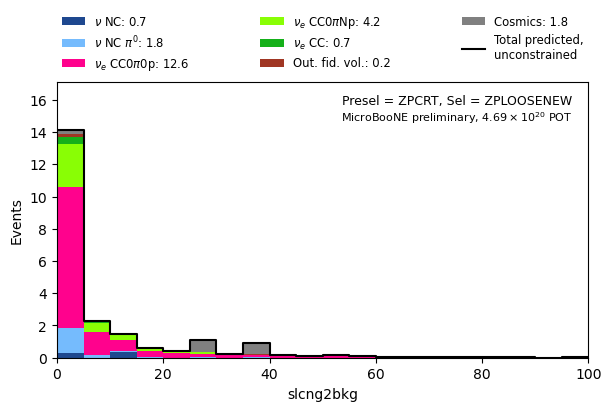

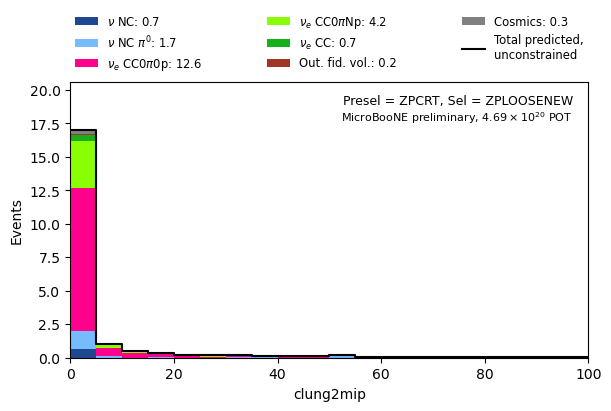

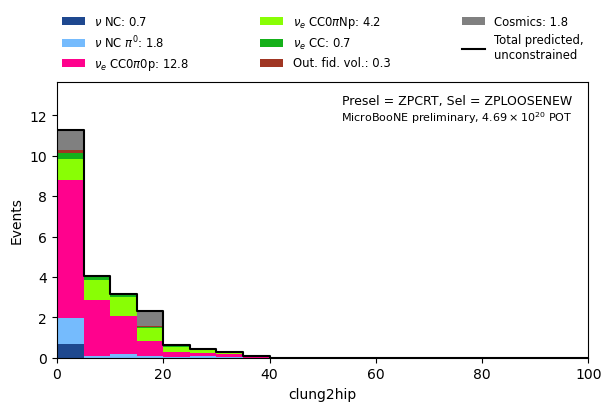

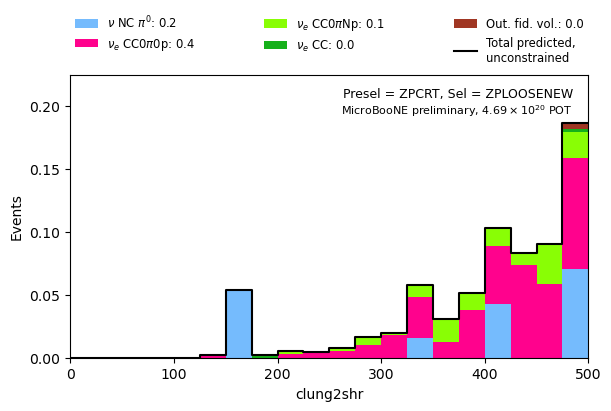

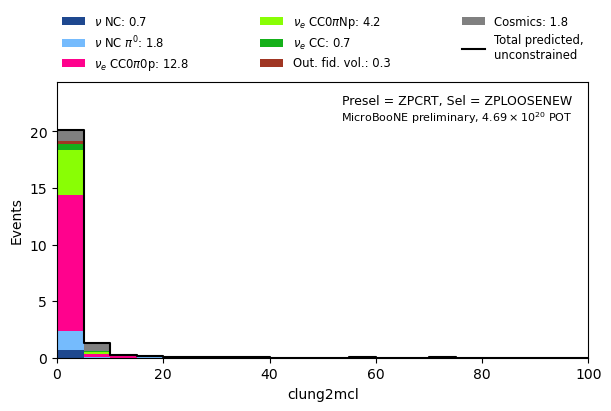

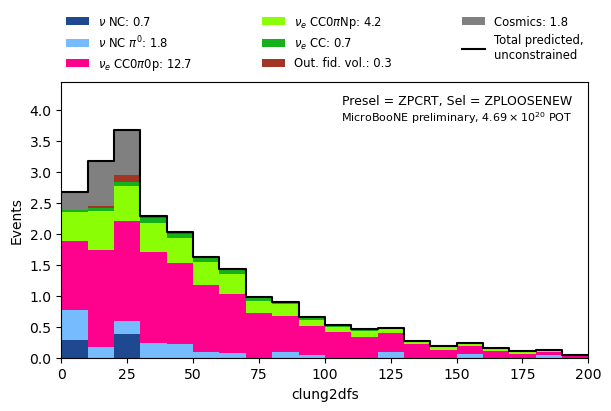

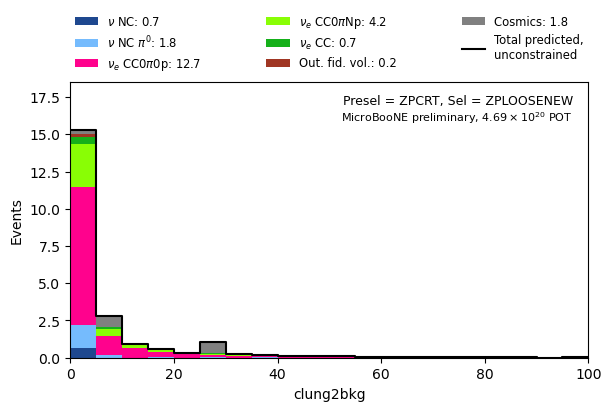

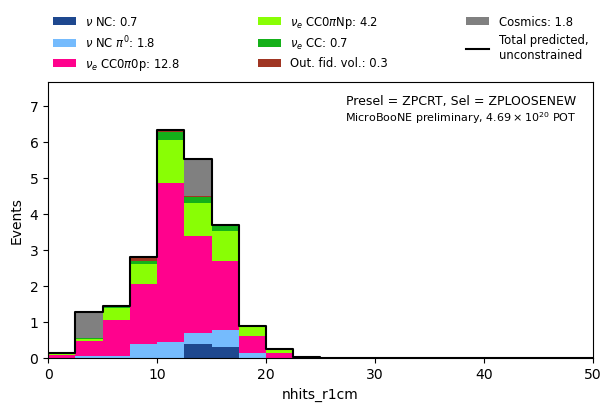

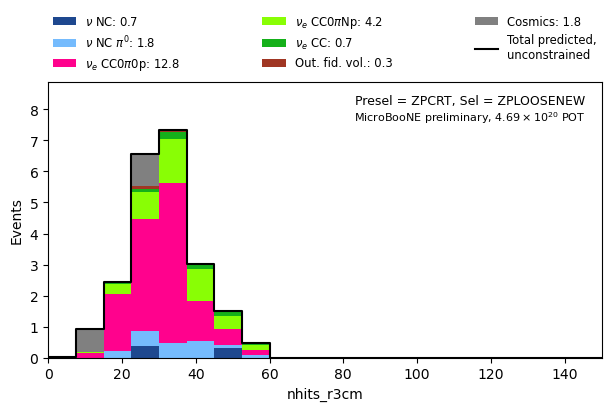

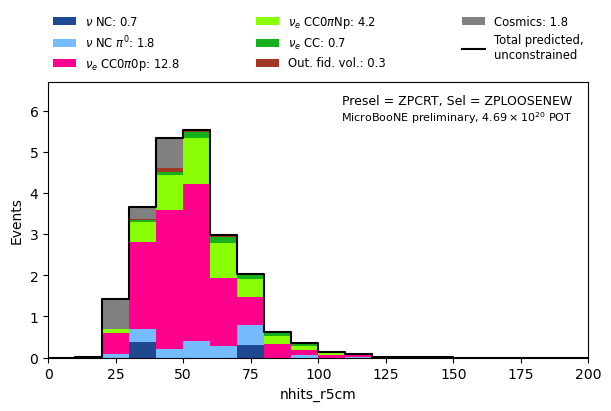

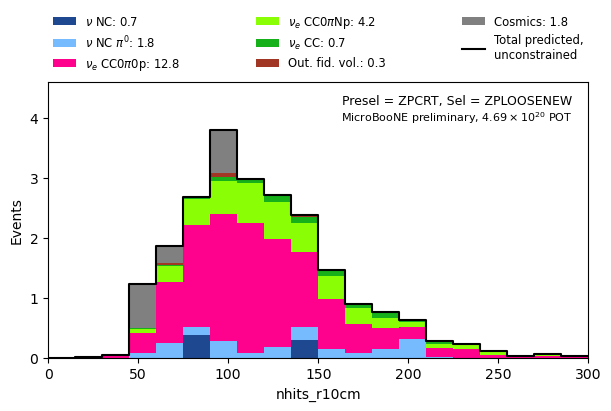

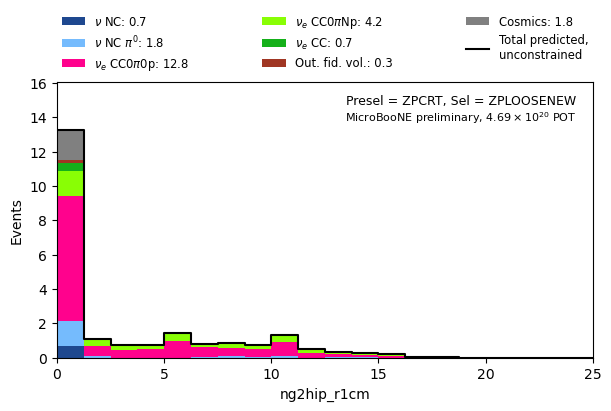

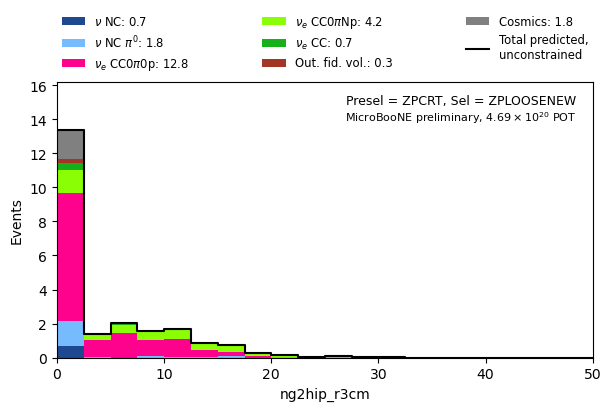

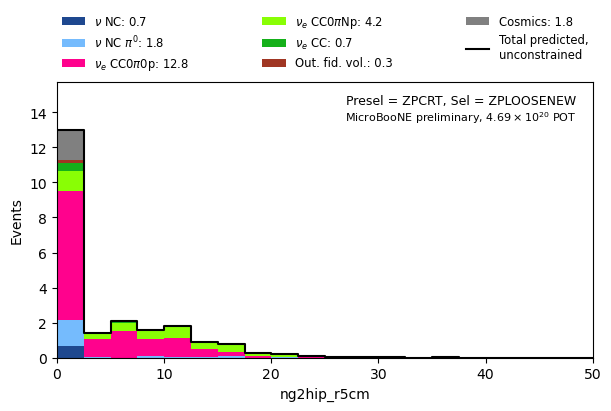

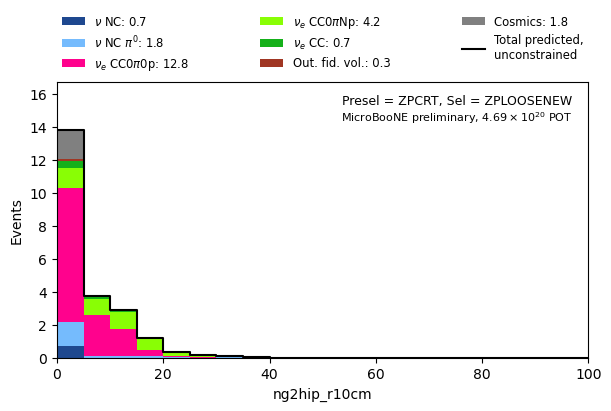

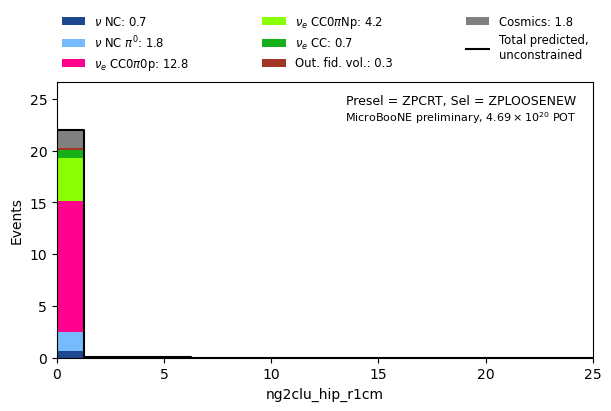

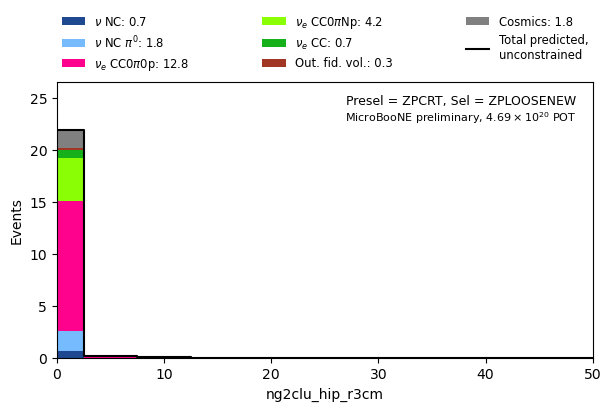

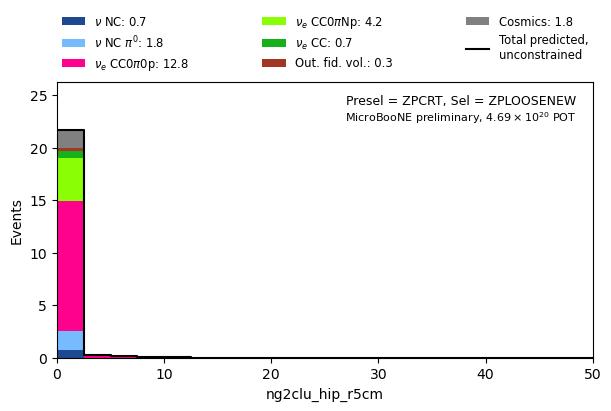

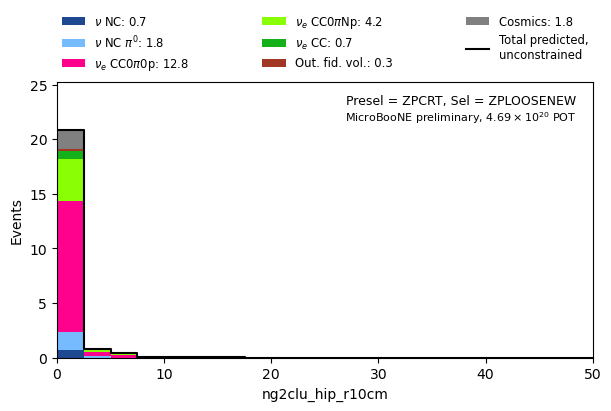

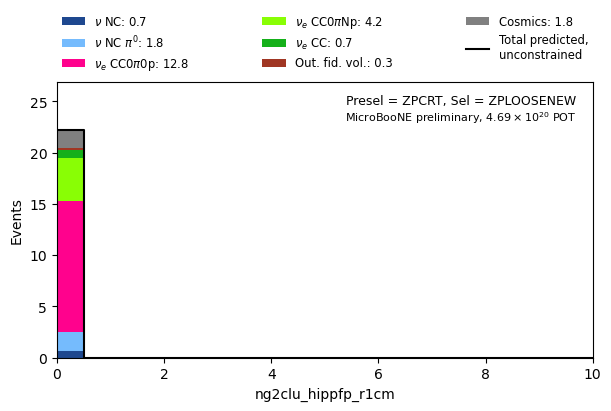

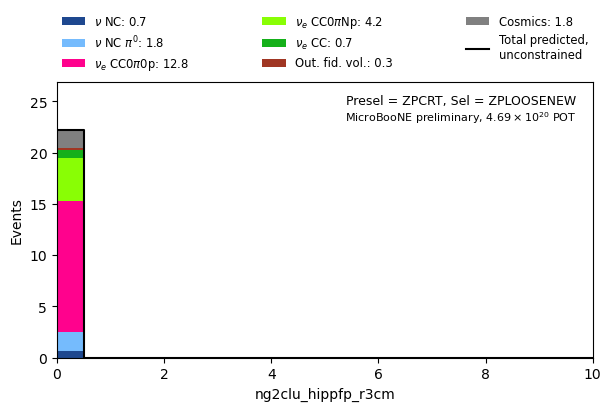

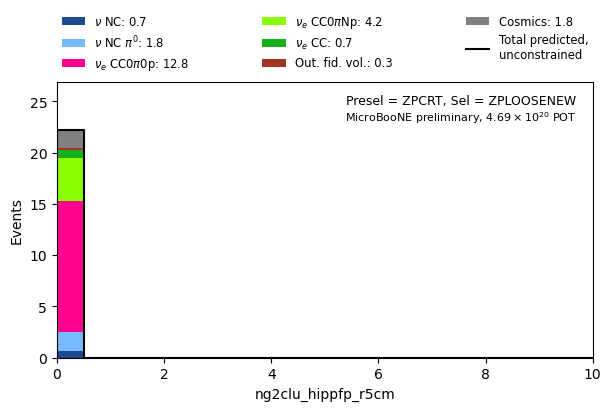

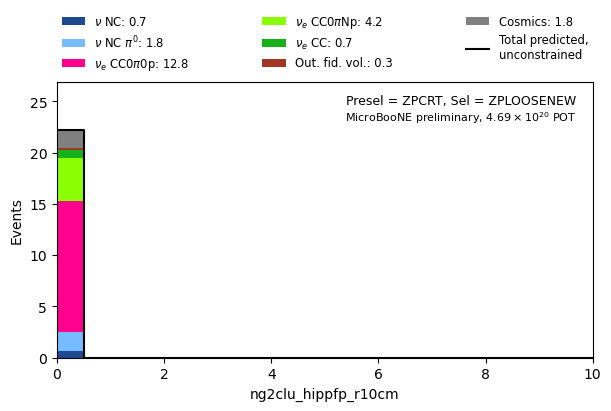

In [13]:
for v in varSet:
    binning_def = v
    binning = Binning.from_config(*binning_def)
    binning.label = preselection
    binning.set_selection(selection, preselection)

    signal_generator = RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
    )

    from microfit.run_plotter import RunHistPlotter

    plotter = RunHistPlotter(signal_generator)

    # Unblinded
    # ax = plotter.plot(
    #     category_column="category",
    #     include_multisim_errors=False,
    #     add_ext_error_floor=False,
    #     show_data_mc_ratio=True,
    #     show_chi_square=True,
    #     title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}',
    # )

    # ax.savefig("run4b_nue_plots.pdf", format="pdf") 

    # Blinded
    ax = plotter.plot(
        category_column="category",
        include_multisim_errors=False,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
        show_total=False,           # Get rid of uncertainty
        title=f'Presel = {binning.preselection_key}, Sel = {binning.selection_key}'
    )